# MSE in the DYAMOND3 simulations

### Imports etc

In [1]:
import datetime as dt
import os
import sys

import cartopy.crs as ccrs
import cmocean as cmo
import easygems.healpix as egh
import healpy as hp
import intake
import matplotlib.pyplot as plt
import metpy.constants as mpconst
import numpy as np
import xarray as xr

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# Filter out annoying warning.
import warnings

from utils import (
    get_nn_lon_lat_index,
    haversine,
    hp_mods,
    hp_to_latlon,
    mass_weighted_column_integral,
)

warnings.filterwarnings(
    "ignore",
    message=".*The return type of `Dataset.dims` will be changed.*",
    category=FutureWarning,
)

In [54]:
zoom=3
url = 'https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml'
cat = intake.open_catalog(url)['UK']
sim = 'um_glm_n2560_RAL3p3_tuned_hk26'
# sim = 'um_glm_n1280_GAL9_v2_hk26'
sim_cat = cat[sim]
ds = sim_cat(zoom=zoom, time='PT3H').to_dask().pipe(hp_mods)
pr = sim_cat(zoom=zoom, time='PT1H').to_dask().pipe(hp_mods).pr
# ds

#### first test calculation

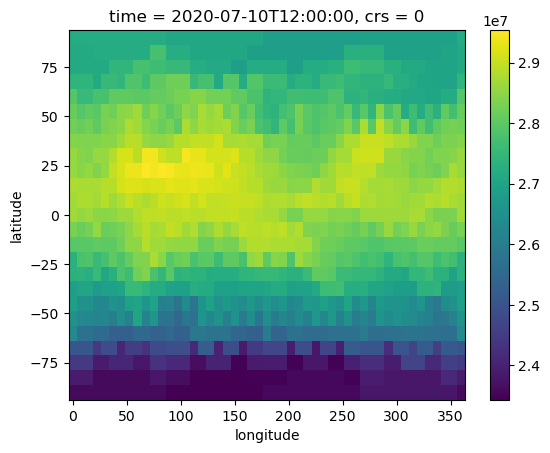

In [55]:
def calc_mse(ds):
    g = mpconst.g.magnitude
    cp = mpconst.dry_air_spec_heat_press.magnitude
    Lv = mpconst.water_heat_vaporization.magnitude
    
    h = cp * ds.ta + ds.zg + Lv * ds.hus
    H = mass_weighted_column_integral(h)
    return H

H=calc_mse(ds)

hp_to_latlon(H.sel(time="2020-07-10 12:00"),zoom=zoom).plot()

#### test line plot of MSE & rainfall at a particular point

In [38]:
dwtps = xr.open_dataset(f"../onset_identification/onset_dates/{sim}_zoom_{zoom}_dwtps.nc")
this_lon=10
this_lat=15
this_loc = dwtps.sel(period=0,longitude=this_lon,latitude=this_lat,method="nearest")
first_date = dt.datetime(2020,1,1) + dt.timedelta(days=int(this_loc.first_day_of_period))
last_date = dt.datetime(2020,1,1) + dt.timedelta(days=int(this_loc.last_day_of_period))

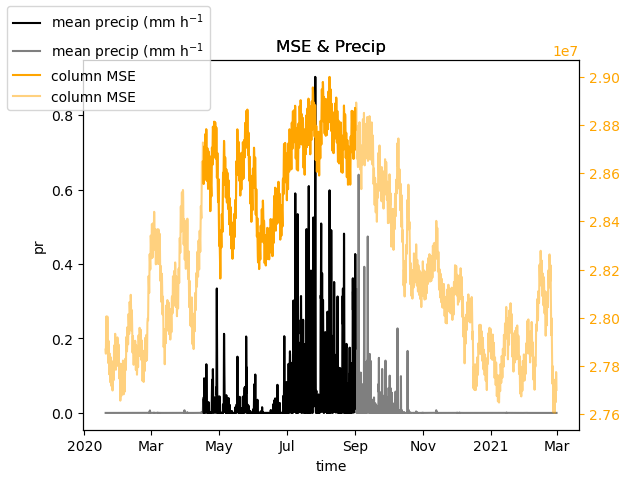

In [39]:
fig, ax1 = plt.subplots()
(
    hp_to_latlon(pr, zoom=zoom)
    .sel(longitude=this_lon, latitude=this_lat, method="nearest")
    .sel(time=slice(first_date, last_date))
    * 3600
).plot(ax=ax1, label="mean precip (mm h$^{-1}$", color="k")

(
    hp_to_latlon(pr, zoom=zoom).sel(
        longitude=this_lon, latitude=this_lat, method="nearest"
    )
    * 3600
).plot(ax=ax1, label="mean precip (mm h$^{-1}$", color="k", alpha=0.5)
ax2 = ax1.twinx()
hp_to_latlon(H, zoom=zoom).sel(
    longitude=this_lon, latitude=this_lat, method="nearest"
).sel(time=slice(first_date, last_date)).plot(
    ax=ax2, label="column MSE", color="orange"
)

hp_to_latlon(H, zoom=zoom).sel(
    longitude=this_lon, latitude=this_lat, method="nearest"
).plot(
    ax=ax2, label="column MSE", color="orange", alpha=0.5
)
ax2.tick_params(axis="y", color="orange", labelcolor="orange")
ax1.set_title("MSE & Precip")
ax2.set_title("MSE & Precip")
fig.legend(loc="upper left")

## Identify energy flux equator

This is defined as the latitude where the meridional gradient of MSE changes sign. 

On HEALpix data, we can use `healpy` to calculate meridional derivatives (in "$\theta$") using spherical harmonics.

This means we get $\dfrac{\partial \text{MSE}}{\partial\theta}$ where $\theta$ is our classical spherical angle measured from the $z$-axis.

Latitude, which we normally call $\phi$, is measured from the south pole upwards, hitting 0 at the equator, which means $\frac{\partial\theta}{\partial \phi}=-1$ so we must convert this by minus 1.

If we want to do the meridional distance gradient we'd need to do another factor of conversion associated with $\frac{\partial y}{\partial \phi}$ but for the purposes of what we want here - a sign change - we can stick with the negative of the pure output of the [`alm2map_der1`](https://healpy.readthedocs.io/en/latest/generated/healpy.sphtfunc.alm2map_der1.html) function, listed as `d_theta` in the docs.

<Figure size 640x480 with 0 Axes>

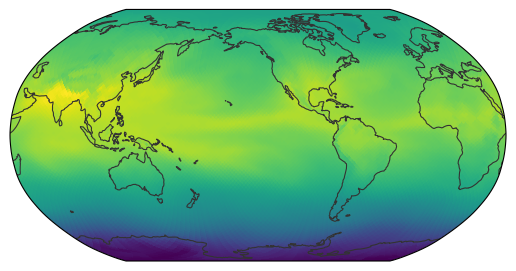

In [124]:
zoom=5
ds = sim_cat(zoom=zoom, time="PT3H").to_dask().rename({"healpix_index": "cell"})
H = calc_mse(ds)
this_time = "2020-07"
this_H = H.sel(time=this_time).mean(dim="time")
this_H_ring = hp.pixelfunc.reorder(this_H.compute().data.squeeze(), inp="NEST", out="RING")
H_alms = hp.sphtfunc.map2alm(this_H_ring)
der1 = hp.sphtfunc.alm2map_der1(H_alms, nside=2**zoom)
egh.healpix_show(this_H)

<Figure size 640x480 with 0 Axes>

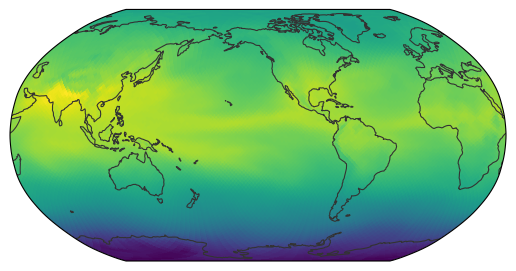

In [125]:
egh.healpix_show(hp.pixelfunc.reorder(der1[0],inp="RING",out="NEST"))


In [126]:
dHdlat = xr.DataArray(
    data=-hp.pixelfunc.reorder(der1[1],inp="RING",out="NEST"),
    coords=this_H.coords,
    dims=this_H.dims,
    name="meridional derivative of MSE",
)

<Figure size 640x480 with 0 Axes>

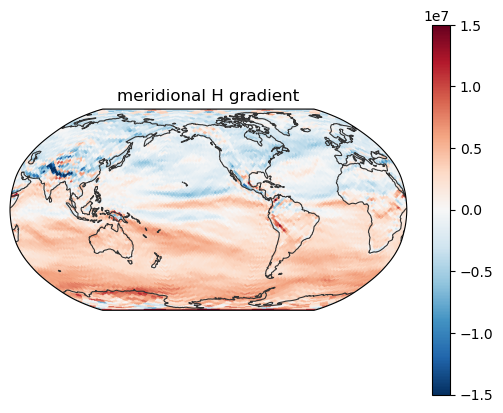

In [129]:
m=egh.healpix_show(dHdlat,cmap="RdBu_r",vmin=-1.5e7,vmax=1.5e7)
plt.title("meridional H gradient")
plt.colorbar(m)

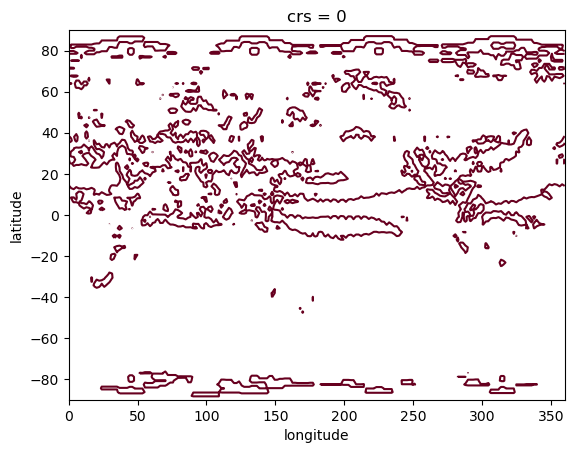

In [128]:
hp_to_latlon(dHdlat,zoom=zoom).plot.contour(levels=[0])


In [44]:
all_sims = [sim for sim in cat]

In [51]:
# Get dataset for all available sims.
zoom = 4
dss = {}
for simname in all_sims:
    try:
        if "um" in simname:
            dss[simname] = cat[simname](time='PT3H', zoom=zoom).to_dask()
        else:
            dss[simname] = cat[simname](zoom=zoom).to_dask()
    except Exception as e:
        print(f'Could not load {simname}')
        print(e)

Could not load IR_IMERG
zoom=4 is not one of the allowed values: 9


Could not load arp-gem-1p3km
zoom=4 is not one of the allowed values: 8
Could not load arp-gem-2p6km
zoom=4 is not one of the allowed values: 8


Could not load ifs_tco3999-ng5_deepoff
zoom=4 is not one of the allowed values: 7,11
Could not load ifs_tco3999-ng5_rcbmf
zoom=4 is not one of the allowed values: 7,11
Could not load ifs_tco3999-ng5_rcbmf_cf
zoom=4 is not one of the allowed values: 7,11
Could not load ifs_tco3999_rcbmf
zoom=4 is not one of the allowed values: 7,11


Could not load tracking-d3hp003
ZarrBackendEntrypoint.open_dataset() got an unexpected keyword argument 'zoom'


Could not load um_CTC_km4p4_RAL3P3_n2560_CoMA9_nest_hk26
'.zmetadata'


In [52]:
def plot_var(plot_dss, var, time, **plot_kwargs):
    """Plot given var from each dataset."""
    rows = maths.ceil(len(plot_dss) / 3)
    projection = ccrs.Robinson(central_longitude=0)
    fig, axes = plt.subplots(rows, 3, figsize=(30, 5 * rows), subplot_kw={'projection': projection}, layout='constrained')
            
    for ax, (name, ds) in zip(axes.flatten(), plot_dss.items()):
        time = pd.Timestamp(ds.time.values[0])
        da = ds[var].sel(time=time).compute()
    
        if abs(da.max() + da.min()) / (da.max() - da.min()) < 0.5:
            # data looks like it needs a diverging cmap.
            # figure out some nice bounds.
            pl, pu = np.percentile(da.values[~np.isnan(da.values)], [2, 98])
            vmax = np.abs([pl, pu]).max()
            kwargs = dict(
                cmap='bwr',
                vmin=-vmax,
                vmax=vmax,
            )
        else:
            kwargs = {}
        kwargs.update(plot_kwargs)
        ax.set_title(f'time: {time} - {name}')
        ax.set_global()
        if ds.attrs.get('regional', False):
            # Display the active chunks for any regional data.
            ds_ones = xr.Dataset({'ones': (['cell'], np.ones_like(ds.isel(time=0).tas))}, coords={'cell': ds.cell}).assign_coords(crs=ds.crs)
            egh.healpix_show(ds_ones.ones, ax=ax)
        im = egh.healpix_show(da, ax=ax, **kwargs);
        long_name = da.long_name
            
        plt.colorbar(im, label=f'{long_name} ({da.attrs.get("units", "-")})')
        ax.coastlines()

In [ ]:
plot_var(dss, 'tas', '2020-01-20 10:00', vmin=215, vmax=310)
